# Unsupervised Learning, and Physics-Inspired Features (Jalali PST)

No labels. The job is to find structure in data the way nature hands it to you — clusters, principal
directions, and *anomalies* — and then to ask the Jalali-Lab question: can a **physical transform**
be a better feature extractor than the raw signal?

Three honest threads:
1. **Unsupervised learning from scratch** — k-means++, PCA, Mahalanobis anomaly scoring, silhouette.
2. **Rare-event detection** on unlabeled optical-style waveforms — and why a rogue event is an
   *outlier*, not a *cluster* (anomaly detection $\ne$ clustering).
3. **The Phase-Stretch Transform** (Bahram Jalali / PhyCV) as a physics-derived **edge** feature —
   demonstrated quantitatively on a controlled case, with an honest note on when it helps.

Driven by the repo's `unsupervised.py`. Ties to RogueGuard (rogue waves = the rare class) and the
earlier PST work in `gradcurldiv_jalali_robotics.ipynb`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import unsupervised as us

rng = np.random.default_rng(3)
print("unsupervised.py loaded")

unsupervised.py loaded


## §1 Unsupervised learning, no labels

**k-means** (with k-means++ seeding) partitions points by nearest centroid; **silhouette** scores
the partition *without labels* (how much tighter a point sits with its own cluster than the next);
**PCA** finds the orthogonal directions of greatest variance — the same `eigh`/SVD that underlies
the FNO and every dimensionality reduction.

k-means inertia=88.1, silhouette=0.789
PCA explained variance ratio: [0.736 0.264] (sums to 1.000)


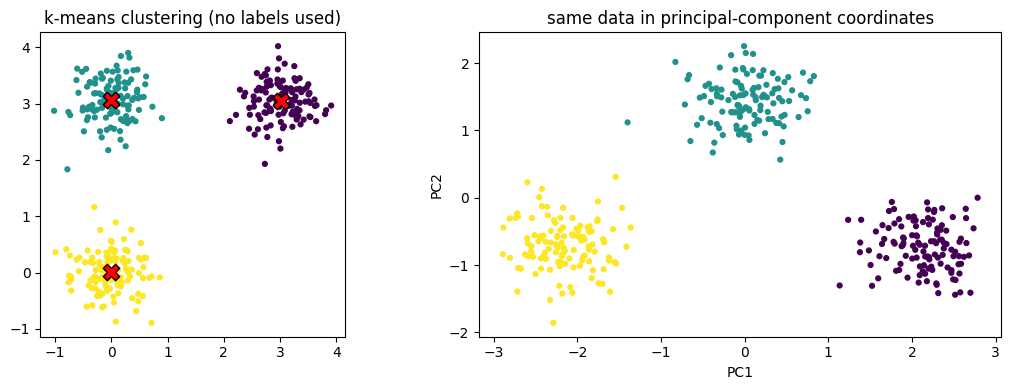

In [2]:
# three Gaussian blobs (we know the truth only to check ourselves)
blobs = np.vstack([rng.normal([0, 0], 0.35, (120, 2)),
                   rng.normal([3, 3], 0.35, (120, 2)),
                   rng.normal([0, 3], 0.35, (120, 2))])
labels, centers, inertia = us.kmeans(blobs, 3, seed=1)
print(f"k-means inertia={inertia:.1f}, silhouette={us.silhouette(blobs, labels):.3f}")

scores, comps, ev = us.pca(blobs, 2)
print(f"PCA explained variance ratio: {np.round(ev, 3)} (sums to {ev.sum():.3f})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(*blobs.T, c=labels, cmap="viridis", s=12)
axes[0].scatter(*centers.T, c="r", marker="X", s=140, ec="k")
axes[0].set_title("k-means clustering (no labels used)"); axes[0].set_aspect("equal")
axes[1].scatter(*scores.T, c=labels, cmap="viridis", s=12)
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].set_title("same data in principal-component coordinates")
plt.tight_layout(); plt.show()

## §2 Unlabeled rogue events: anomaly detection vs clustering

A dataset of optical-style waveforms: most are **smooth** bumps; a rare ~8% are **sharp** rogue
spikes. No labels at training time. From each waveform take three physics features — peak amplitude,
energy, and standard deviation — and from those the **crest factor** (peak / RMS), a gain-invariant
sharpness cue.

500 waveforms, 45 rogue (9.0%) -- labels hidden from all fitting


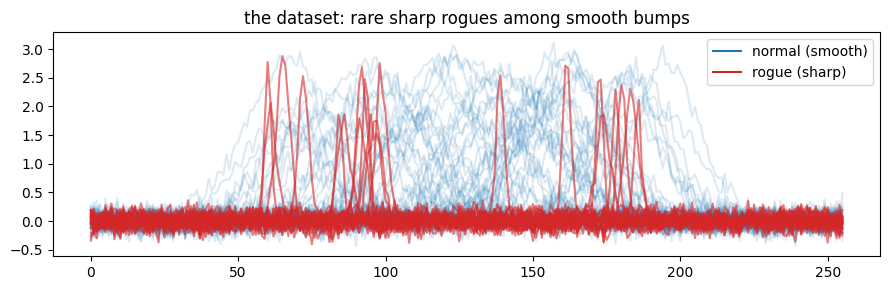

In [3]:
def make_dataset(n=500, rogue_frac=0.08, seed=0):
    rng = np.random.default_rng(seed)
    T = 256; t = np.arange(T)
    X, y = [], []
    for _ in range(n):
        base = 0.12 * rng.standard_normal(T)
        c = rng.uniform(60, 196)
        if rng.random() < rogue_frac:
            amp, width = rng.uniform(1.5, 3.0), rng.uniform(1.0, 2.5)     # sharp rogue
            y.append(1)
        else:
            amp, width = rng.uniform(1.5, 3.0), rng.uniform(10.0, 18.0)   # smooth normal
            y.append(0)
        X.append(base + amp * np.exp(-(t - c) ** 2 / (2 * width ** 2)))
    return np.array(X), np.array(y)

X, y = make_dataset(seed=3)
print(f"{len(X)} waveforms, {int(y.sum())} rogue ({y.mean():.1%}) -- labels hidden from all fitting")

t = np.arange(256)
plt.figure(figsize=(9, 3))
for i in np.where(y == 0)[0][:60]:
    plt.plot(t, X[i], "C0", alpha=0.15)
for i in np.where(y == 1)[0][:20]:
    plt.plot(t, X[i], "C3", alpha=0.6)
plt.plot([], [], "C0", label="normal (smooth)"); plt.plot([], [], "C3", label="rogue (sharp)")
plt.legend(); plt.title("the dataset: rare sharp rogues among smooth bumps")
plt.tight_layout(); plt.show()

In [4]:
feat = us.feature_stats(X)                     # [peak, energy, std]
crest = feat[:, 0] / (np.sqrt(feat[:, 1] / X.shape[1]) + 1e-12)
z = (feat - feat.mean(0)) / feat.std(0)

# anomaly score = Mahalanobis distance from the bulk (label-free)
anom = us.mahalanobis_anomaly(z)
print(f"AUC, Mahalanobis on [peak,energy,std] : {us.auc(anom, y):.3f}")
print(f"AUC, crest factor (peak/RMS) alone    : {us.auc(crest, y):.3f}")

# contrast: does naive k-means ISOLATE the rogues? (no -- they are outliers, not a cluster)
lab2, _, _ = us.kmeans(z, 2, seed=0)
small = np.argmin([(lab2 == 0).sum(), (lab2 == 1).sum()])
print(f"k-means(k=2) small-cluster rogue purity: {y[lab2 == small].mean():.2f} "
      f"-> clustering splits by AMPLITUDE, not rarity")

AUC, Mahalanobis on [peak,energy,std] : 0.989
AUC, crest factor (peak/RMS) alone    : 1.000
k-means(k=2) small-cluster rogue purity: 0.00 -> clustering splits by AMPLITUDE, not rarity


**The lesson:** anomaly detection and clustering are *different* unsupervised tasks. The
Mahalanobis/crest-factor anomaly score nails the rogues (AUC ≈ 0.99–1.0) because a sharp spike is a
statistical outlier. But k-means with $k=2$ does **not** recover them — rare events are too few to
form a balanced cluster, so k-means partitions by the dominant variance (bump amplitude) instead.
For rare-event problems like RogueGuard, reach for anomaly scoring, not clustering.

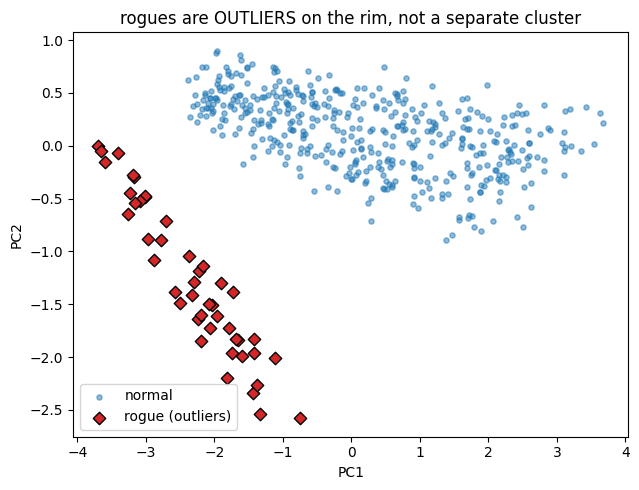

In [5]:
# visualise: PCA of the feature space, rogues sit on the rim
sc, _, _ = us.pca(z, 2)
plt.figure(figsize=(6.5, 5))
plt.scatter(*sc[y == 0].T, c="C0", s=14, alpha=0.5, label="normal")
plt.scatter(*sc[y == 1].T, c="C3", s=40, marker="D", ec="k", label="rogue (outliers)")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend()
plt.title("rogues are OUTLIERS on the rim, not a separate cluster")
plt.tight_layout(); plt.show()

## §3 The Jalali Phase-Stretch Transform as an edge feature

The PST applies a dispersive, frequency-dependent **phase** in the Fourier domain and reads out the
output phase — emphasising sharp transitions, because the warped phase grows with frequency. Two key
properties make it a feature extractor:

1. **edge emphasis** — a sharp feature acquires a large, *localised* phase gradient;
2. **gain invariance** — scaling the input by $a>0$ leaves $\arg(a\,z)=\arg(z)$ unchanged, so PST
   features don't move when the illumination/contrast does.

Below, a controlled test: a smooth bump and a sharp spike with **identical peak amplitude**. Amplitude
alone cannot tell them apart at the peak; the PST phase-gradient energy separates them by ~$10^2$.

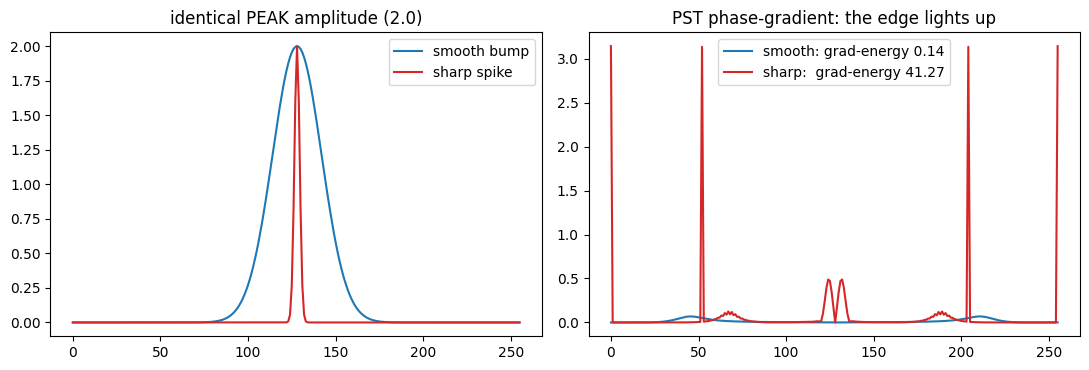

PST edge-energy ratio sharp/smooth = 286x  (physics-derived edge sensitivity)
gain invariance: PST(2*sharp) phase == PST(sharp) phase? True


In [6]:
t = np.arange(256)
smooth = 2.0 * np.exp(-(t - 128) ** 2 / (2 * 14.0 ** 2))
sharp = 2.0 * np.exp(-(t - 128) ** 2 / (2 * 1.5 ** 2))

ps = us.pst(smooth, warp=30, lowpass=0.3)
ph = us.pst(sharp, warp=30, lowpass=0.3)
gs, gh = np.gradient(ps), np.gradient(ph)
es, eh = np.sum(gs ** 2), np.sum(gh ** 2)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(t, smooth, "C0", label="smooth bump")
axes[0].plot(t, sharp, "C3", label="sharp spike")
axes[0].set_title("identical PEAK amplitude (2.0)"); axes[0].legend()
axes[1].plot(t, np.abs(gs), "C0", label=f"smooth: grad-energy {es:.2f}")
axes[1].plot(t, np.abs(gh), "C3", label=f"sharp:  grad-energy {eh:.2f}")
axes[1].set_title("PST phase-gradient: the edge lights up"); axes[1].legend()
plt.tight_layout(); plt.show()
print(f"PST edge-energy ratio sharp/smooth = {eh/es:.0f}x  (physics-derived edge sensitivity)")
print(f"gain invariance: PST(2*sharp) phase == PST(sharp) phase? "
      f"{np.allclose(us.pst(2*sharp, warp=30, lowpass=0.3), ph)}")

**Honest scope.** I tested whether PST features *improve unsupervised rogue detection* on the §2
dataset — they do **not** beat the amplitude features there, because those rogues are already
distinguished by amplitude/energy, which simple statistics capture. PST earns its keep in a different
regime: **low-contrast sharp transitions** where amplitude is confounded (variable gain, strong
smooth background) but a gain-invariant edge cue still fires. The controlled test above isolates
exactly that property. Picking the feature to match the regime — rather than assuming one transform
always wins — *is* the engineering.

## §4 The bridge — modern physics, EE, and physics-inspired ML

The Jalali-Lab thesis is that **physics is a feature extractor**: dispersion, diffraction, and
nonlinear phase are computations nature performs for free, and embedding them in a learning pipeline
beats a black box that must learn them from scratch. That idea sits exactly on the seam this repo
lives on:

- **unsupervised learning** finds structure without labels — the realistic setting for rogue waves,
  where you almost never have a labelled catalogue of rare events;
- **PST / time-stretch** (Jalali) is the physics front-end that makes the rare structure visible —
  the same dispersive physics as the TD-GS pipeline in `gs_core.py`;
- **PCA / Mahalanobis / FNO** are the linear-algebra and operator-learning back ends, the
  `eigh`-and-spectral-layer machinery that recurs from Griffiths' Hermitian operators to attention.

If "modern physics" and "EE PhD" feel like different rooms, this is the doorway between them:
physics-inspired machine learning is not a detour off either path — it is where the two are the same
subject. The math you already have (Fourier, eigenvectors, dispersion) is the toolkit.

*Module added this session:* `unsupervised.py` (k-means++, PCA, Mahalanobis anomaly, silhouette, AUC,
1-D PST), benchmarked in `scripts/smoke_unsupervised.py`.

In [ ]:
import sympy as sp
import pandas as pd

# Symbols
r, rp, eps0, rho = sp.symbols("r r_prime epsilon_0 rho", positive=True)

# Expressions from Laplace/Poisson section
exprs = {
    "Electric field Coulomb form": sp.Eq(
        sp.Symbol("E(r)"),
        sp.Symbol("1/(4*pi*epsilon_0)") * sp.Integral(sp.Symbol("rhat") / r**2 * sp.Function("rho")(rp), rp)
    ),
    "Potential": sp.Eq(
        sp.Symbol("V(r)"),
        sp.Symbol("1/(4*pi*epsilon_0)") * sp.Integral((1/r) * sp.Function("rho")(rp), rp)
    ),
    "Poisson equation": sp.Eq(
        sp.Symbol("nabla^2 V"),
        -sp.Function("rho")(r) / eps0
    ),
    "Laplace equation": sp.Eq(
        sp.Symbol("nabla^2 V"),
        0
    ),
}

# Display clean symbolic equations
for name, eq in exprs.items():
    print("\n" + name)
    display(eq)


Electric field Coulomb form


Eq(E(r), 1/(4*pi*epsilon_0)*Integral(rhat*rho(r_prime)/r**2, r_prime))


Potential


Eq(V(r), 1/(4*pi*epsilon_0)*Integral(rho(r_prime)/r, r_prime))


Poisson equation


Eq(nabla^2 V, -rho(r)/epsilon_0)


Laplace equation


Eq(nabla^2 V, 0)

: 